# Getting Started: VarQITE for H2

This notebook runs a minimal **Variational Quantum Imaginary-Time Evolution
(VarQITE)** workflow for the hydrogen molecule **H2**.

Goals:

- run a small VarQITE calculation
- inspect the energy trajectory
- compare the final result with the exact ground-state energy
- reconstruct the final statevector from the stored output

This is the smallest end-to-end imaginary-time workflow in the repository.

In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from common.hamiltonian import get_exact_spectrum
from qite import run_qite

## Why VarQITE?

**VarQITE** evolves a variational state in imaginary time:

$$
|\psi(\tau)\rangle \propto e^{-\tau H} |\psi(0)\rangle
$$

Imaginary-time evolution suppresses higher-energy components, so the state is
driven toward the ground state when the ansatz is expressive enough.

In this repository, VarQITE is implemented through a McLachlan-projected
variational update.

## Exact ground-state reference

For a small system like `H2`, we can compare the final VarQITE energy against
the exact ground-state value.

In [2]:
exact_spectrum = np.asarray(get_exact_spectrum("H2"), dtype=float)
exact_spectrum = np.sort(exact_spectrum)

exact_ground_energy = float(exact_spectrum[0])
exact_ground_energy

-1.1372701748841751

## Run a minimal VarQITE calculation

We use:

- molecule: `H2`
- ansatz: `UCCSD`
- a modest number of imaginary-time steps
- a small imaginary-time step size `dtau`

VarQITE in this package is a pure-state workflow, so noisy simulation is not
used here.

In [3]:
res = run_qite(
    molecule="H2",
    ansatz_name="UCCSD",
    steps=50,
    dtau=0.2,
    seed=0,
    noisy=False,
    force=True,
    plot=False,
)


⚙️ Using VarQITE (McLachlan) update rule
Iter 01/50: E = -1.127748 Ha
Iter 02/50: E = -1.132890 Ha
Iter 03/50: E = -1.135261 Ha
Iter 04/50: E = -1.136349 Ha


Iter 05/50: E = -1.136849 Ha
Iter 06/50: E = -1.137077 Ha
Iter 07/50: E = -1.137182 Ha
Iter 08/50: E = -1.137230 Ha
Iter 09/50: E = -1.137252 Ha
Iter 10/50: E = -1.137262 Ha
Iter 11/50: E = -1.137266 Ha
Iter 12/50: E = -1.137268 Ha
Iter 13/50: E = -1.137269 Ha
Iter 14/50: E = -1.137270 Ha
Iter 15/50: E = -1.137270 Ha
Iter 16/50: E = -1.137270 Ha
Iter 17/50: E = -1.137270 Ha
Iter 18/50: E = -1.137270 Ha
Iter 19/50: E = -1.137270 Ha
Iter 20/50: E = -1.137270 Ha
Iter 21/50: E = -1.137270 Ha
Iter 22/50: E = -1.137270 Ha
Iter 23/50: E = -1.137270 Ha
Iter 24/50: E = -1.137270 Ha
Iter 25/50: E = -1.137270 Ha
Iter 26/50: E = -1.137270 Ha
Iter 27/50: E = -1.137270 Ha
Iter 28/50: E = -1.137270 Ha
Iter 29/50: E = -1.137270 Ha
Iter 30/50: E = -1.137270 Ha
Iter 31/50: E = -1.137270 Ha
Iter 32/50: E = -1.137270 Ha
Iter 33/50: E = -1.137270 Ha
Iter 34/50: E = -1.137270 Ha
Iter 35/50: E = -1.137270 Ha
Iter 36/50: E = -1.137270 Ha
Iter 37/50: E = -1.137270 Ha
Iter 38/50: E = -1.137270 Ha
Iter 39/50: E 

In [4]:
sorted(res.keys())

['ansatz',
 'basis',
 'charge',
 'dtau',
 'energies',
 'energy',
 'final_params',
 'final_params_shape',
 'final_state_imag',
 'final_state_real',
 'mapping',
 'molecule',
 'num_qubits',
 'steps',
 'unit',
 'varqite']

## Final energy

The main quantity of interest is the final variational energy after the last
imaginary-time update.

In [5]:
final_energy = float(res["energy"])
final_energy

-1.1372701748841756

## Energy trajectory

VarQITE returns the full energy trace, including the initial point.

In [6]:
energies = np.asarray(res["energies"], dtype=float)
energies

array([-1.11668439, -1.12774823, -1.13289036, -1.13526082, -1.13634944,
       -1.1368485 , -1.13707711, -1.13718179, -1.13722971, -1.13725165,
       -1.1372617 , -1.13726629, -1.1372684 , -1.13726936, -1.1372698 ,
       -1.13727   , -1.1372701 , -1.13727014, -1.13727016, -1.13727017,
       -1.13727017, -1.13727017, -1.13727017, -1.13727017, -1.13727017,
       -1.13727017, -1.13727017, -1.13727017, -1.13727017, -1.13727017,
       -1.13727017, -1.13727017, -1.13727017, -1.13727017, -1.13727017,
       -1.13727017, -1.13727017, -1.13727017, -1.13727017, -1.13727017,
       -1.13727017, -1.13727017, -1.13727017, -1.13727017, -1.13727017,
       -1.13727017, -1.13727017, -1.13727017, -1.13727017, -1.13727017,
       -1.13727017])

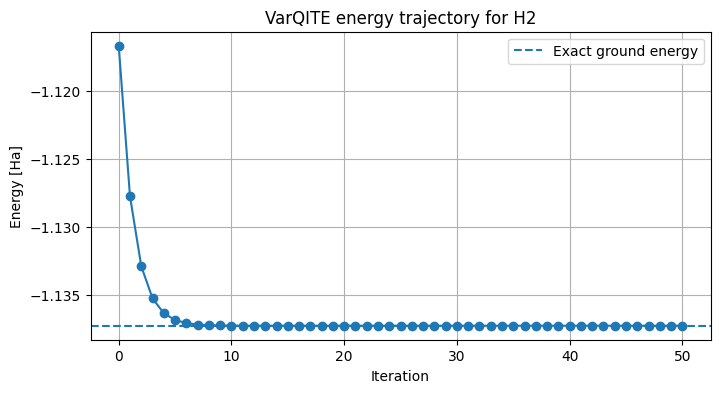

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(np.arange(len(energies)), energies, marker="o")
plt.axhline(exact_ground_energy, linestyle="--", label="Exact ground energy")
plt.xlabel("Iteration")
plt.ylabel("Energy [Ha]")
plt.title("VarQITE energy trajectory for H2")
plt.grid(True)
plt.legend()
plt.show()

## Compare against the exact ground-state energy

In [8]:
abs_error = abs(final_energy - exact_ground_energy)

print(f"VarQITE final energy : {final_energy:.10f}")
print(f"Exact ground energy  : {exact_ground_energy:.10f}")
print(f"Absolute error       : {abs_error:.6e}")

VarQITE final energy : -1.1372701749
Exact ground energy  : -1.1372701749
Absolute error       : 4.440892e-16


## Final-state reconstruction

The result stores the final state as separate real and imaginary components.
We reconstruct the statevector and inspect the dominant basis amplitudes.

In [9]:
psi_real = np.asarray(res["final_state_real"], dtype=float)
psi_imag = np.asarray(res["final_state_imag"], dtype=float)
psi = psi_real + 1j * psi_imag

num_qubits = int(res["num_qubits"])
num_qubits

4

In [10]:
threshold = 1e-2
idx = np.where(np.abs(psi) > threshold)[0]

print(f"Significant components (|c_i| > {threshold:g}):")
for i in idx:
    amp = psi[i]
    bitstring = format(i, f"0{num_qubits}b")
    print(f"|{bitstring}> : {amp.real:.6f}{amp.imag:+.6f}j   |c_i|={abs(amp):.6f}")

Significant components (|c_i| > 0.01):
|0011> : -0.112827+0.000000j   |c_i|=0.112827
|1100> : 0.993615+0.000000j   |c_i|=0.993615


## Amplitude magnitudes

A small bar plot makes the dominant computational-basis support easier to see.

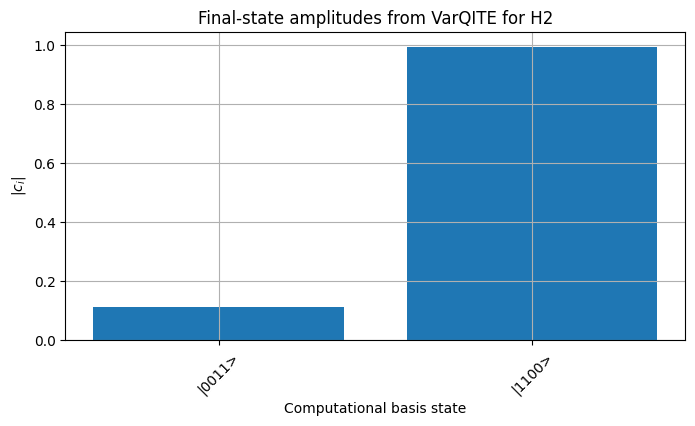

In [11]:
labels = [f"|{i:0{num_qubits}b}>" for i in idx]
magnitudes = np.abs(psi[idx])

plt.figure(figsize=(8, 4))
plt.bar(labels, magnitudes)
plt.xlabel("Computational basis state")
plt.ylabel(r"$|c_i|$")
plt.title("Final-state amplitudes from VarQITE for H2")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Interpretation

A useful way to think about the methods in this repository is:

- **VQE** minimizes an energy expectation value directly
- **VarQITE** follows an imaginary-time projected update
- **QPE** extracts eigenvalue information from phase evolution

All three workflows use the same Hamiltonian pipeline, so comparisons across
methods are physically consistent.

## What this notebook showed

We:

- ran a minimal VarQITE workflow for `H2`
- inspected the returned energy trajectory
- compared the final energy with the exact ground-state reference
- reconstructed the final statevector from the stored output

This is the basic imaginary-time workflow in the repository.